# scVIVA for representing cells and their environment in spatial transcriptomics
In this tutorial, we go through the steps of training scVIVA, a deep generative model that leverages both cell-intrinsic and neighboring gene expression profiles to produce stochastic embeddings of cell states as well as normalized gene expression profiles. We show how to obtain informative fine-grained partitions of cells that reflects both their internal state and the surrounding tissue and use the generative model to test hypotheses of differential expression between tissue niches.

Plan for this tutorial:

1. Loading the data
2. Training a scVIVA model
3. Visualizing the latent space
4. Perform DE analysis across niches

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Install from GitHub for now
!pip install --quiet scviva-tools
!pip install --quiet adjustText


[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [3]:
import os
import random
import tempfile
import rapids_singlecell as rsc
import scvi
import numpy as np  
import scanpy as sc  
import scviva  
import torch  
from rich import print  

/opt/anaconda3/envs/scvi_new/lib/python3.13/site-packages/rapids_singlecell/__init__.py:38: UserWarning: 
Multiple rapids_singlecell packages are installed: rapids-singlecell, rapids-singlecell-cu13
Please uninstall all versions and reinstall only one:
  pip uninstall rapids-singlecell rapids-singlecell-cu13

  _detect_duplicate_installation()


In [4]:
sc.set_figure_params(figsize=(4, 4))
save_dir = tempfile.TemporaryDirectory()
%config InlineBackend.print_figure_kwargs={'facecolor' : "w"}
%config InlineBackend.figure_format='retina'

scviva.settings.seed = 0
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
print("Last run with scVIVA-Tools version:", scviva.__version__)

INFO: Seed set to 0
2026-09-09 14:20:02 | [INFO] Seed set to 0


Last run with scVIVA-Tools version: 0.1.6

In [5]:
scvi.settings.seed = 0
print("Last run with scvi-tools version:", scvi.__version__)

INFO: Seed set to 0
2026-09-09 14:20:02 | [INFO] Seed set to 0


Last run with scvi-tools version: 1.5.0.post1

In [6]:
# Quickly check the correct folder is used.
scviva.__file__

'/opt/anaconda3/envs/scvi_new/lib/python3.13/site-packages/scviva/__init__.py'

## Data loading

In this tutorial we load a human breast cancer section, generated with [10X Xenium](https://www.nature.com/articles/s41467-023-43458-x).
The cell segmentation originally performed on this data resulted in many erroneously assigned transcripts and therefore re-segmented the cells using the [ProSeg](https://www.biorxiv.org/content/10.1101/2024.04.25.591218v1) algorithm, which is a scalable algorithm for transcriptome-informed segmentation.

In [7]:
adata_path = os.path.join(save_dir.name, "adata_for_tuto_s1.h5ad")
adata = sc.read(
    adata_path,
    backup_url="https://exampledata.scverse.org/scvi-tools/adata_for_tuto_s1.h5ad",
)
adata

  0%|          | 0.00/1.11G [00:00<?, ?B/s]

AnnData object with n_obs × n_vars = 117305 × 313
    obs: 'sample', 'x', 'y', 'z', 'observed_x', 'observed_y', 'observed_z', 'fov', 'n_counts', 'index', 'cell_type'
    var: 'mt'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'log1p', 'pca'
    obsm: 'X_pca', 'X_scANVI', 'spatial'
    varm: 'PCs'
    layers: 'counts', 'counts_log1p', 'counts_wo_bg', 'min_max_scaled', 'min_max_scaled_raw', None (.X)

The authors identified distinct tumor domains in this specimen, corresponding to in situ ductal carcinoma (DCIS) and invasive tumor:

/tmp/ipykernel_1000565/2186789331.py:1: FutureWarning: The function spatial is deprecated and will be removed in the future. Use :func:`squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color="cell_type", spot_size=30)


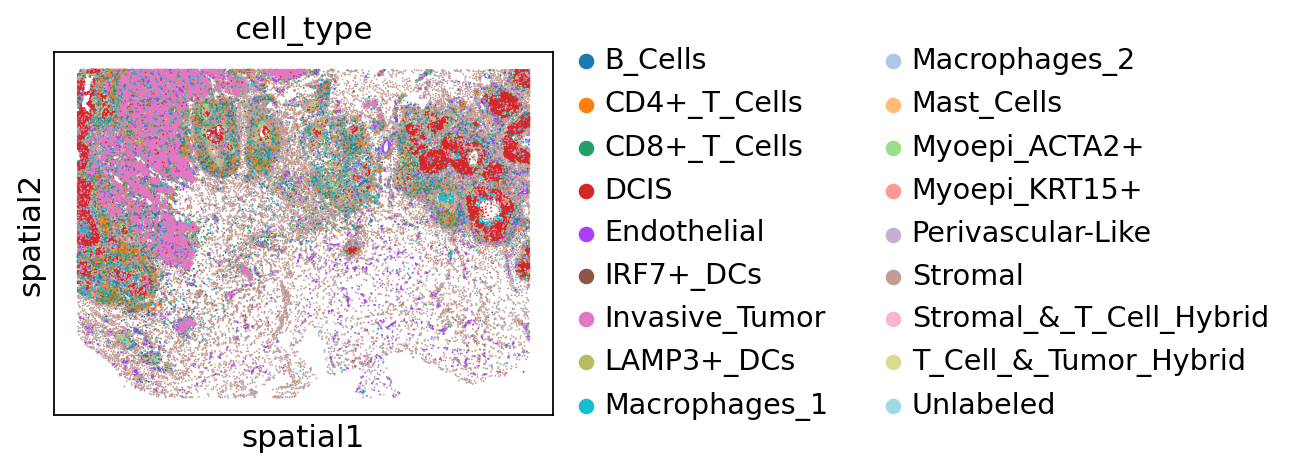

In [8]:
sc.pl.spatial(adata, color="cell_type", spot_size=30)

In [9]:
adata.obs["cell_type"].value_counts()

cell_type
Stromal                    32426
Invasive_Tumor             18185
DCIS                       15993
CD4+_T_Cells                9387
Macrophages_1               8644
CD8+_T_Cells                7493
Endothelial                 7000
B_Cells                     5359
Myoepi_ACTA2+               5324
Myoepi_KRT15+               2636
Macrophages_2               2616
Perivascular-Like            817
Unlabeled                    516
IRF7+_DCs                    454
LAMP3+_DCs                   218
Mast_Cells                   203
Stromal_&_T_Cell_Hybrid       28
T_Cell_&_Tumor_Hybrid          6
Name: count, dtype: int64

## Train scVIVA model

We first define the neighborhood of each cell using a k-nn graph. We set $k=20$. Then, the environment features are defined in two ways - the first is the cell-type composition of its cellular neighborhood. The second is the average gene expression state of neighboring cells, with a separate profile for each of the present cell types. These cell-intrinsic gene expression states can be learned with a spatially unaware model such as scANVI, or with resolVI.

Here we assume that scANVI has already been trained on the data, and that the embeddings are stored in the AnnData object. We refer to the scANVI tutorial for training the model.


Environment features computations occur in the `preprocessing_anndata` method, that adds the relevant keys to the AnnData object.

In [10]:
setup_kwargs = {
    "sample_key": "sample",  # column in adata.obs that contains the individual slide ID
    "labels_key": "cell_type",  # column in adata.obs that contains the cell type labels
    "cell_coordinates_key": "spatial",  # spatial coordinates key in adata.obsm
    "expression_embedding_key": "X_scANVI",  # expression embedding key in adata.obsm
}

In [11]:
from scviva.model._scviva import SCVIVA

In [12]:
scviva.model.SCVIVA.preprocessing_anndata(
    adata,
    k_nn=20,  # number of nearest neighbors for spatial graph construction
    **setup_kwargs,
)

Saved niche_indexes and niche_distances in adata.obsm

Saved niche_composition in adata.obsm

Saved niche_activation in adata.obsm

Then, as in all scvi-tools model, we need to register the AnnData.

In [13]:
scviva.model.SCVIVA.setup_anndata(
    adata,
    layer="counts",  # adata layer that contains the raw counts
    batch_key="sample",  # column in adata.obs that contains the batch covariate
    **setup_kwargs,
)

INFO     Using column names from columns of adata.obsm['niche_composition']                                        
INFO     Generating sequential column names                                                                        
INFO     Generating sequential column names                                                                        
INFO     Generating sequential column names                                                                        
INFO     Generating sequential column names                                                                        
INFO     Generating sequential column names                                                                        


We instantiate a scVIVA model:

In [14]:
nichevae = scviva.model.SCVIVA(adata)

nichevae

scVIVA model with the following parameters: 
n_hidden: 128, n_latent: 10, n_layers: 1, dropout_rate: 0.1, dispersion: gene, gene_likelihood: poisson, 
latent_distribution: normal.
Training status: Not Trained
Model's adata is minified?: False

In [15]:
nichevae.train(
    max_epochs=600,
    early_stopping=True,
    check_val_every_n_epoch=1,
    batch_size=512,
    plan_kwargs={
        "lr": 5e-4,
    },
)

/opt/anaconda3/envs/scvi_new/lib/python3.13/site-packages/torch/cuda/__init__.py:1174: UserWarning: Can't initialize NVML
  raw_cnt = _raw_device_count_nvml()
INFO: GPU available: True (cuda), used: True
2026-09-09 14:20:23 | [INFO] GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
2026-09-09 14:20:23 | [INFO] TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
2026-09-09 14:20:23 | [INFO] 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/opt/anaconda3/envs/scvi_new/lib/python3.13/site-packages/torch/cuda/__init__.py:1174: UserWarning: Can't initialize

Training:   0%|          | 0/600 [00:00<?, ?it/s]

Monitored metric elbo_validation did not improve in the last 45 records. Best score: 239.113. Signaling Trainer to stop.


We can plot the training curves:

In [16]:
nichevae.history.keys()

dict_keys(['kl_weight', 'validation_loss', 'elbo_validation', 'reconstruction_loss_validation', 'kl_local_validation', 'kl_global_validation', 'niche_compo_validation', 'niche_reconst_validation', 'train_loss', 'elbo_train', 'reconstruction_loss_train', 'kl_local_train', 'kl_global_train', 'niche_compo_train', 'niche_reconst_train'])

Let's plot for instance the validation ELBO, niche composition and state losses:

<Axes: xlabel='epoch'>

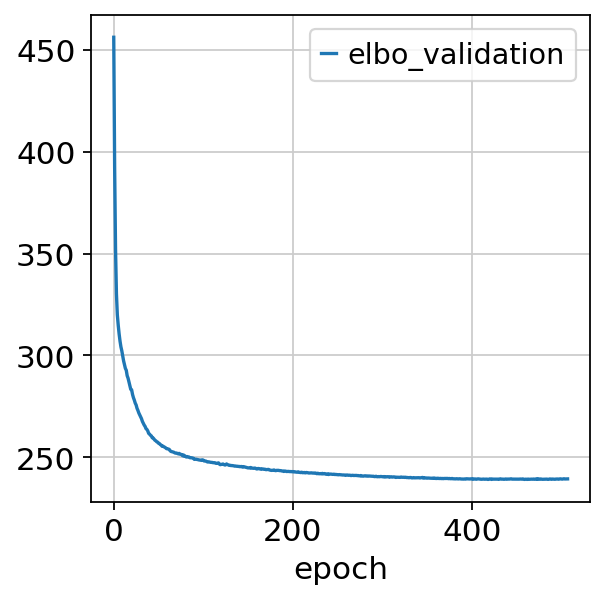

In [17]:
nichevae.history["elbo_validation"].plot()

<Axes: xlabel='epoch'>

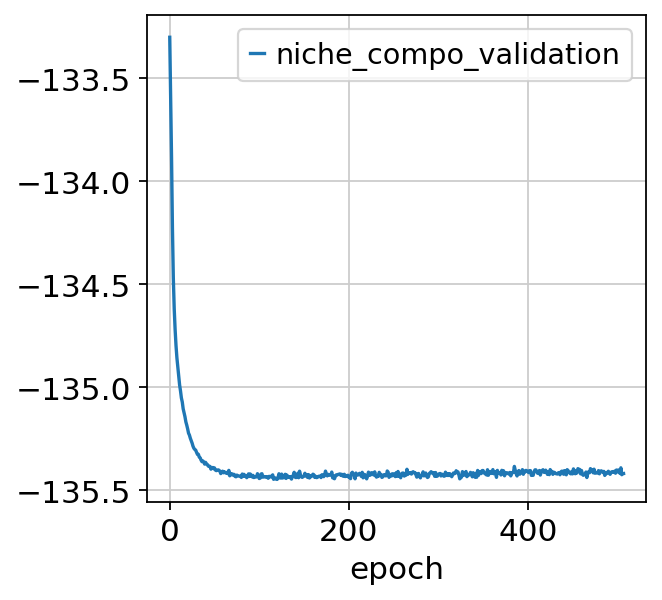

In [18]:
nichevae.history["niche_compo_validation"].plot()

<Axes: xlabel='epoch'>

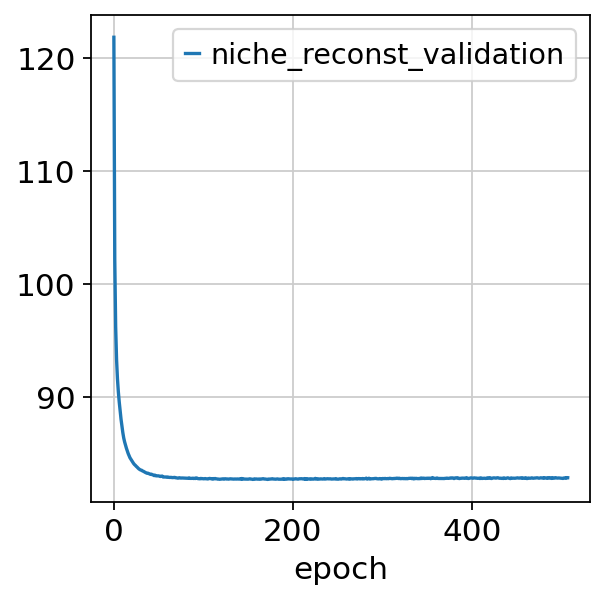

In [19]:
nichevae.history["niche_reconst_validation"].plot()

<Axes: xlabel='epoch'>

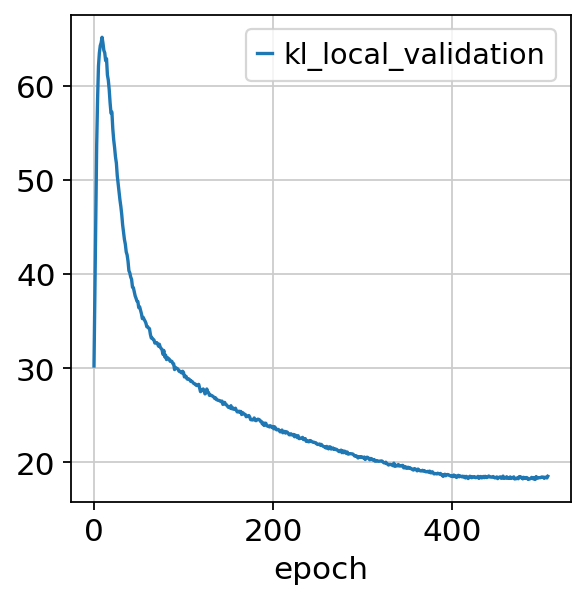

In [20]:
nichevae.history["kl_local_validation"].plot()

<Axes: xlabel='epoch'>

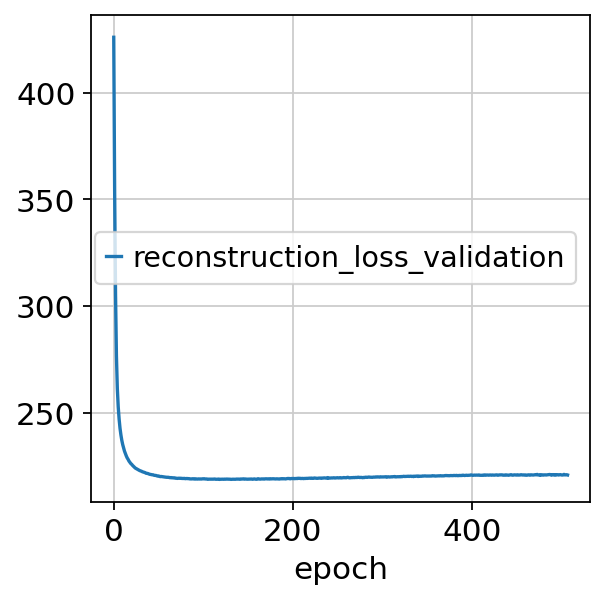

In [21]:
nichevae.history["reconstruction_loss_validation"].plot()

After training the model, we can compute and store the latent space:

In [22]:
adata.obsm["X_scVIVA"] = nichevae.get_latent_representation()

We may visualize the latent space in UMAP coordinates, coloring by cell type.

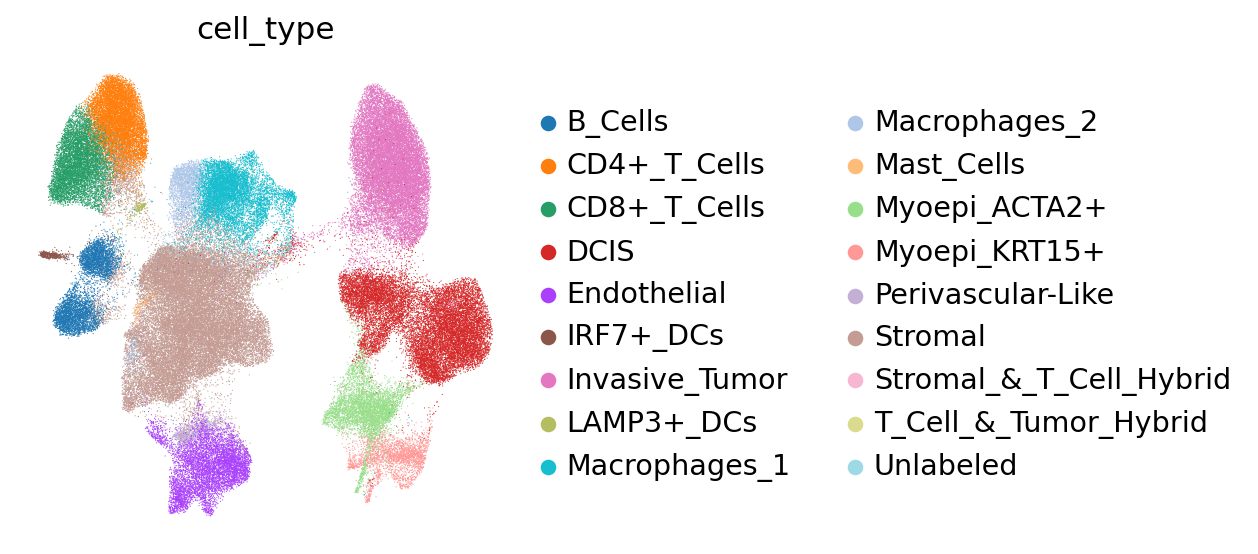

In [23]:
rsc.pp.neighbors(adata, use_rep="X_scVIVA", n_neighbors=30)
rsc.tl.umap(adata)

sc.pl.umap(adata, color="cell_type", frameon=False)

## Differential expression analysis

We now use the generative model to test hypotheses of differential expression between the niches. We'll focus on endothelial cells.

In [24]:
adata_endothelial = adata[adata.obs["cell_type"] == "Endothelial"].copy()
adata_not_endo = adata[adata.obs["cell_type"] != "Endothelial"].copy()

print(adata_endothelial)

AnnData object with n_obs × n_vars = 7000 × 313
    obs: 'sample', 'x', 'y', 'z', 'observed_x', 'observed_y', 'observed_z', 'fov', 'n_counts', 'index', 
'cell_type', '_scvi_batch', '_scvi_labels', '_scvi_sample'
    var: 'mt'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'log1p', 'pca', 'cell_type_colors', 'cell_type_to_int', 'neighbors', 
'umap'
    obsm: 'X_pca', 'X_scANVI', 'spatial', 'niche_indexes', 'niche_distances', 'niche_composition', 
'niche_activation', 'X_scVIVA', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'
    layers: 'counts', 'counts_log1p', 'counts_wo_bg', 'min_max_scaled', 'min_max_scaled_raw', None (.X)

We perform coarse Leiden clustering on the endothelial latent space, in a bid to find spatially confined populations of endothelial cells.

In [25]:
rsc.pp.neighbors(adata_endothelial, use_rep="X_scVIVA", n_neighbors=30, random_state=42)
rsc.tl.umap(adata_endothelial)
sc.tl.leiden(
    adata_endothelial,
    key_added="leiden_scVIVA",
    resolution=0.3,
    flavor="igraph",
    n_iterations=-1,
    random_state=42,
)

In [26]:
adata_endothelial.obs["leiden_scVIVA"].unique()  # check the number of clusters

['0', '1', '2', '3']
Categories (4, object): ['0', '1', '2', '3']

We focus on clusters 0 and 1, which are located in the stromal and tumor regions, respectively. We then perform differential expression analysis between these two clusters.

/tmp/ipykernel_1000565/3415536345.py:1: FutureWarning: The function spatial is deprecated and will be removed in the future. Use :func:`squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


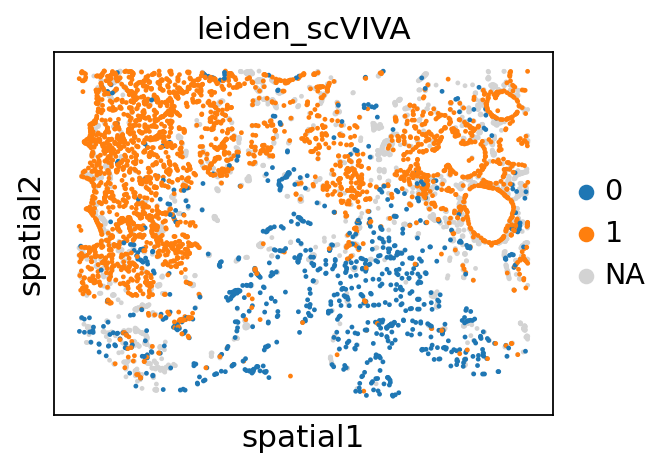

In [27]:
sc.pl.spatial(
    adata_endothelial,
    color="leiden_scVIVA",
    spot_size=80,
    groups=["1", "0"],
)

In [28]:
adata.obs["leiden_scVIVA"] = "Unknown"
adata.obs.loc[adata.obs["cell_type"] == "Endothelial", "leiden_scVIVA"] = adata_endothelial.obs[
    "leiden_scVIVA"
]

In [29]:
adata.obs["leiden_scVIVA"].value_counts()

leiden_scVIVA
Unknown    110305
1            3234
2            2279
0             879
3             608
Name: count, dtype: int64

We now run the differential expression function, between the cell groups $\textit{G1}=tumor~endothelial$ and $\textit{G2}=stromal~endothelial$. We first set the number of nearest neighbors to compute the non-endothelial neighbors of $\textit{G1}$ and $\textit{G2}$, called $\textit{N1}$ and $\textit{N2}$, respectively.

Setting `niche_mode=True`, we compute 4 different DE tests:  $\{\textit{G1}~vs~\textit{G2}\}$,  $\{\textit{G1}~vs~\textit{N1}\}$,  $\{\textit{N1}~vs~\textit{G2}\}$ and $\{\textit{N1}~vs~\textit{N2}\}$ (in this order). We set a test-specific treshold for significant log-fold change `DELTA`.

Other parameters include the number of samples to draw from the posterior `N_SAMPLES_DE`, `PSEUDOCOUNTS` for stability and `FDR` for the FDR correction. More details can be found in Boyeau et al. PNAS 2023.




In [30]:
delta_niches = 0.05  # smaller delta for niche comparison
delta_markers = 0.15  # bigger delta for G1-N1 comparison
DELTA = [delta_niches, delta_markers, delta_niches, delta_niches]


K_NN_DE = 6

GROUP = "leiden_scVIVA"
G1 = "1"
G2 = "0"
PSEUDOCOUNTS = 1e-4
N_SAMPLES_DE = 1e5
FDR = 0.2

DE_1_0 = nichevae.differential_expression(
    adata,
    groupby=GROUP,
    group1=G1,
    group2=G2,
    k_nn=K_NN_DE,
    delta=DELTA,
    niche_mode=True,
    n_samples_overall=N_SAMPLES_DE,
    fdr_target=FDR,
    pseudocounts=PSEUDOCOUNTS,
)

Computing adjusted nearest neighbors...

Using 1 samples

Mean number of neighbors: 3.3 ± 2.1

Computing DE...

DE...:   0%|          | 0/1 [00:00<?, ?it/s]

Running DE for group1_group2

Running DE for group1_neighbors1

Running DE for neighbors1_group2

Running DE for neighbors1_neighbors2

Computing g1 confidence scores...

/opt/anaconda3/envs/scvi_new/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__alpha is close to the specified upper bound 1.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/anaconda3/envs/scvi_new/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 10.0. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Let's analysize the DE test: $\textit{G1}=tumor~endothelial$ vs $\textit{G2}=stromal~endothelial$. The DE function returns a Dataclass object `DE_1_0`.

We can access the Gaussian process classifier properties with the `gpc` attribute:

In [31]:
DE_1_0.gpc

,"kernel kernel: kernel instance, default=NoneThe kernel specifying the covariance function of the GP. If None ispassed, the kernel ""1.0 * RBF(1.0)"" is used as default. Note thatthe kernel's hyperparameters are optimized during fitting. Also kernelcannot be a `CompoundKernel`.",1**2 * Ration...ngth_scale=10)
,"optimizer optimizer: 'fmin_l_bfgs_b', callable or None, default='fmin_l_bfgs_b'Can either be one of the internally supported optimizers for optimizingthe kernel's parameters, specified by a string, or an externallydefined optimizer passed as a callable. If a callable is passed, itmust have the signature:: def optimizer(obj_func, initial_theta, bounds): # * 'obj_func' is the objective function to be maximized, which # takes the hyperparameters theta as parameter and an # optional flag eval_gradient, which determines if the # gradient is returned additionally to the function value # * 'initial_theta': the initial value for theta, which can be # used by local optimizers # * 'bounds': the bounds on the values of theta .... # Returned are the best found hyperparameters theta and # the corresponding value of the target function. return theta_opt, func_minPer default, the 'L-BFGS-B' algorithm from scipy.optimize.minimizeis used. If None is passed, the kernel's parameters are kept fixed.Available internal optimizers are:: 'fmin_l_bfgs_b'",'fmin_l_bfgs_b'
,"n_restarts_optimizer n_restarts_optimizer: int, default=0The number of restarts of the optimizer for finding the kernel'sparameters which maximize the log-marginal likelihood. The first runof the optimizer is performed from the kernel's initial parameters,the remaining ones (if any) from thetas sampled log-uniform randomlyfrom the space of allowed theta-values. If greater than 0, all boundsmust be finite. Note that n_restarts_optimizer=0 implies that onerun is performed.",10
,"max_iter_predict max_iter_predict: int, default=100The maximum number of iterations in Newton's method for approximatingthe posterior during predict. Smaller values will reduce computationtime at the cost of worse results.",100
,"warm_start warm_start: bool, default=FalseIf warm-starts are enabled, the solution of the last Newton iterationon the Laplace approximation of the posterior mode is used asinitialization for the next call of _posterior_mode(). This can speedup convergence when _posterior_mode is called several times on similarproblems as in hyperparameter optimization. See :term:`the Glossary`.",False
,"copy_X_train copy_X_train: bool, default=TrueIf True, a persistent copy of the training data is stored in theobject. Otherwise, just a reference to the training data is stored,which might cause predictions to change if the data is modifiedexternally.",True
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation used to initialize the centers.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",0
,"multi_class multi_class: {'one_vs_rest', 'one_vs_one'}, default='one_vs_rest'Specifies how multi-class classification problems are handled.Supported are 'one_vs_rest' and 'one_vs_one'. In 'one_vs_rest',one binary Gaussian process classifier is fitted for each class, whichis trained to separate this class from the rest. In 'one_vs_one', onebinary Gaussian process classifier is fitted for each pair of classes,which is trained to separate these two classes. The predictions ofthese binary predictors are combined into multi-class predictions.Note that 'one_vs_one' does not support predicting probabilityestimates.",'one_vs_rest'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation: the specifiedmulticlass problems are computed in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,kernel__k1,1**2
,kernel__k2,RationalQuadr...ngth_scale=10)


In [32]:
DE_1_0.gpc_info()

Training score:  0.8859649122807017

Marginal likelihood:  -30.162392186710726

Kernel:  27.8**2 * RationalQuadratic(alpha=1, length_scale=10)

The $\textit{G1}$ vs $\textit{G2}$ differential expression results are stored in the `g1_g2` attribute:

In [33]:
DE_1_0.g1_g2

,proba_de,proba_not_de,bayes_factor,scale1,scale2,pseudocounts,delta,lfc_mean,lfc_median,lfc_std,...,raw_mean2,non_zeros_proportion1,non_zeros_proportion2,raw_normalized_mean1,raw_normalized_mean2,is_de_fdr_0.2,comparison,group1,group2,proba_de_g1_n1
CAVIN2,0.95831,0.04169,3.134910,0.003555,0.015147,0.0001,0.05,-2.259335,-2.233523,1.303981,...,4.021615,0.335189,0.849829,36.052235,165.609848,True,1 vs 0,1,0,0.000000
ADH1B,0.94897,0.05103,2.922963,0.000442,0.027187,0.0001,0.05,-5.882402,-5.967785,3.472863,...,8.400455,0.037724,0.494881,3.153913,236.927306,True,1 vs 0,1,0,0.000000
ESM1,0.94399,0.05601,2.824585,0.009155,0.000439,0.0001,0.05,4.068509,4.128297,2.473642,...,0.077361,0.351577,0.052332,94.064393,3.298118,True,1 vs 0,1,0,0.947434
NCAM1,0.94395,0.05605,2.823829,0.000191,0.001072,0.0001,0.05,-2.787509,-2.809119,1.684214,...,0.424346,0.029066,0.254835,1.872793,17.873268,True,1 vs 0,1,0,0.000000
ZEB1,0.93878,0.06122,2.730107,0.013903,0.006903,0.0001,0.05,0.984324,1.001840,0.608163,...,1.847554,0.754174,0.693970,144.321340,69.428389,True,1 vs 0,1,0,0.978962
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
QARS,0.46810,0.53190,-0.127774,0.004332,0.004433,0.0001,0.05,-0.027033,-0.017748,0.411831,...,1.094425,0.465368,0.527873,42.754478,38.950771,False,1 vs 0,1,0,0.000000
SLC25A37,0.46789,0.53211,-0.128617,0.001218,0.001285,0.0001,0.05,-0.060211,-0.017859,0.491845,...,0.325370,0.182746,0.213879,12.858891,12.913242,False,1 vs 0,1,0,0.000000
HPX,0.43327,0.56673,-0.268522,0.000090,0.000090,0.0001,0.05,-0.001137,-0.008018,0.725234,...,0.021615,0.019790,0.018203,1.347470,0.815830,False,1 vs 0,1,0,0.000000
SLC4A1,0.43296,0.56704,-0.269784,0.000053,0.000049,0.0001,0.05,0.093599,0.036830,0.792679,...,0.010239,0.006494,0.009101,0.399164,0.298773,False,1 vs 0,1,0,0.086502


Where the probability of true DE according to the Gaussian process classifier is stored in the `proba_de_g1_n1` column:

In [34]:
DE_1_0.g1_g2["proba_de_g1_n1"]

CAVIN2      0.000000
ADH1B       0.000000
ESM1        0.947434
NCAM1       0.000000
ZEB1        0.978962
              ...   
QARS        0.000000
SLC25A37    0.000000
HPX         0.000000
SLC4A1      0.086502
CCL20       0.006752
Name: proba_de_g1_n1, Length: 313, dtype: float64

We may also access the other tests results in the same way: `DE_1_0.g1_n1`, `DE_1_0.n1_g2` and `DE_1_0.n1_n2`.

We can then filter genes to upregulated genes, i.e. such that the median Log-Fold Change over the samples is positive, and the `proba_de` (ratio of LFC greater than the defined delta treshold over the total number of posterior samples) is greater than a given filter - here we set it to 0.8.

In [35]:
PROBA_TRES = 0.8

g1_g3_genes = DE_1_0.g1_g2[
    (DE_1_0.g1_g2["lfc_median"] > 0) & (DE_1_0.g1_g2["proba_de"] > PROBA_TRES)
].index

We then display the results: median Log-Fold Change (LFC) of upregulated genes in $\textit{G1}$ vs $\textit{G2}$ displayed on the x-axis, while we compare differential expression computed between $\textit{N1}$  and $\textit{G2}$ on the y-axis.

Genes are colored by their marker label (yellow=significantly upregulated in $\textit{G1}$ vs $\textit{N1}$, green otherwise).

We also display the classifier decision boundary (the predicted probability of being in the yellow class).

/opt/anaconda3/envs/scvi_new/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but GaussianProcessClassifier was fitted with feature names
  warnings.warn(


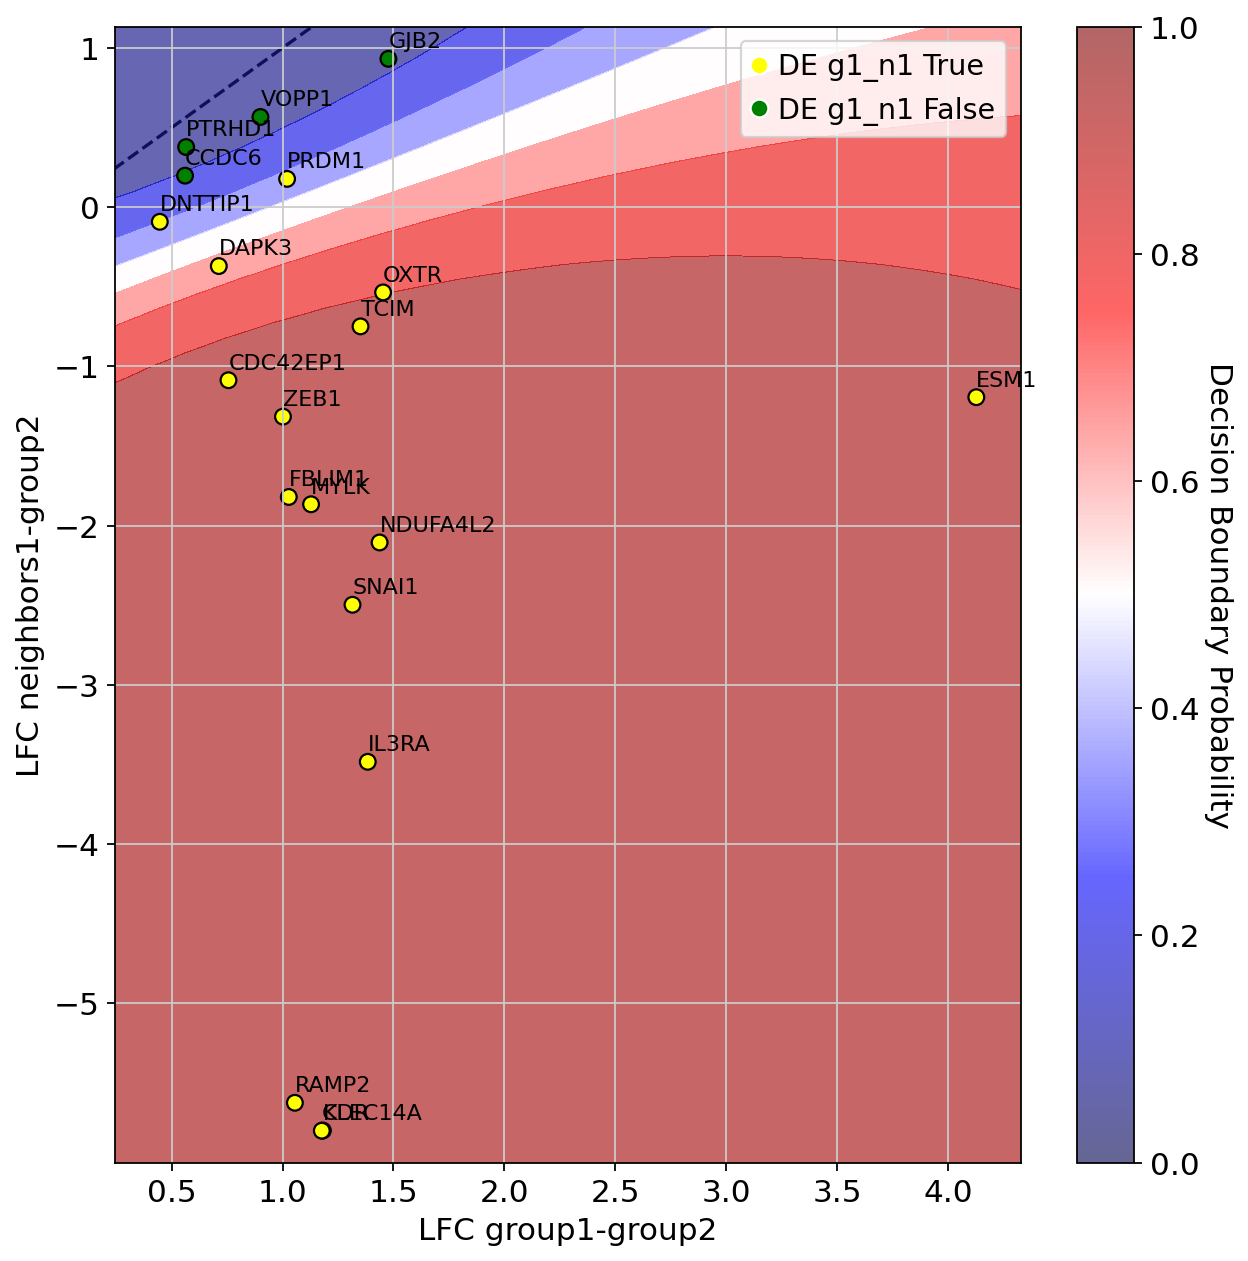

In [36]:
PLOT_MARGIN = 0.2

DE_1_0.plot(
    filter=g1_g3_genes,  # selected genes to plot
    # path_to_save="DE_plot.svg",
    margin=PLOT_MARGIN,  # margin around the plot
    legend_loc="upper right",  # location of the legend
)

You can select the marker genes (positive class for the classifier, yellow in the plot):

In [37]:
DE_1_0.gpc.confident_genes

Index(['ESM1', 'ZEB1', 'TCIM', 'NDUFA4L2', 'DAPK3', 'DNTTIP1', 'CDC42EP1',
       'PRDM1', 'IL3RA', 'RAMP2', 'KDR', 'SNAI1', 'MYLK', 'FBLIM1', 'CLEC14A',
       'OXTR'],
      dtype='object')

We can also check the predicted class probabilities of the Gaussian process classifier:

In [38]:
DE_1_0.g1_g2["proba_de_g1_n1"].loc[DE_1_0.gpc.confident_genes]

ESM1        0.947434
ZEB1        0.978962
TCIM        0.935717
NDUFA4L2    0.995126
DAPK3       0.662048
DNTTIP1     0.303608
CDC42EP1    0.951858
PRDM1       0.343782
IL3RA       0.994210
RAMP2       0.964569
KDR         0.961288
SNAI1       0.996010
MYLK        0.993043
FBLIM1      0.992092
CLEC14A     0.961228
OXTR        0.897306
Name: proba_de_g1_n1, dtype: float64

Then we can further filter the confident gene list, by setting a treshold on the classifier predictions - for instance 0.9:

In [39]:
DE_1_0.g1_g2["proba_de_g1_n1"].loc[DE_1_0.gpc.confident_genes][
    DE_1_0.g1_g2["proba_de_g1_n1"].loc[DE_1_0.gpc.confident_genes] > 0.9
].index

Index(['ESM1', 'ZEB1', 'TCIM', 'NDUFA4L2', 'CDC42EP1', 'IL3RA', 'RAMP2', 'KDR',
       'SNAI1', 'MYLK', 'FBLIM1', 'CLEC14A'],
      dtype='object')

Finally, we can plot spatial maps of the selected genes. We first compute global percentiles of the gene expression values to set an upper bound for the color scale.

In [40]:
def get_gene_percentiles_list(adata, gene_list, p, layer=None):
    """
    Calculate the p-percentile of gene expression for a list of genes in an AnnData object.

    Parameters
    ----------
        adata (AnnData): The AnnData object containing expression data.
        gene_list (list): List of gene names for which to compute percentiles.
        p (float): Percentile to compute (between 0 and 100).
        layer (str or None): The layer from which to retrieve expression data.
                             If None, uses `adata.X`.

    Returns
    -------
        list: A list of p-percentile values for the genes, in the same order as gene_list.
              If a gene is not found, its value will be `None`.
    """
    percentiles = []

    for gene in gene_list:
        if gene in adata.var_names:
            if layer:
                data = adata[:, gene].layers[layer].flatten()
            else:
                data = adata[:, gene].X.flatten()

            # Compute the percentile
            percentiles.append(np.percentile(data, p))
        else:
            percentiles.append(None)  # Handle genes not in adata.var_names

    return percentiles

We display _ESM1_, _KDR_, _SNAI1_, critical genes for angiogenesis in invasive cancer. We aslo display _FOXA1_, that is both upregulated in $\textit{G1}$ and $\textit{N1}$, to show how our procedure can filter such genes.

In [41]:
gene_list_invasive = ["ESM1", "KDR", "SNAI1", "FOXA1"]
percentiles_invasive = get_gene_percentiles_list(
    adata, gene_list_invasive, 99.9, layer="min_max_scaled"
)

We first plot these genes in endothelial cells:

/tmp/ipykernel_1000565/3718530031.py:3: FutureWarning: The function spatial is deprecated and will be removed in the future. Use :func:`squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


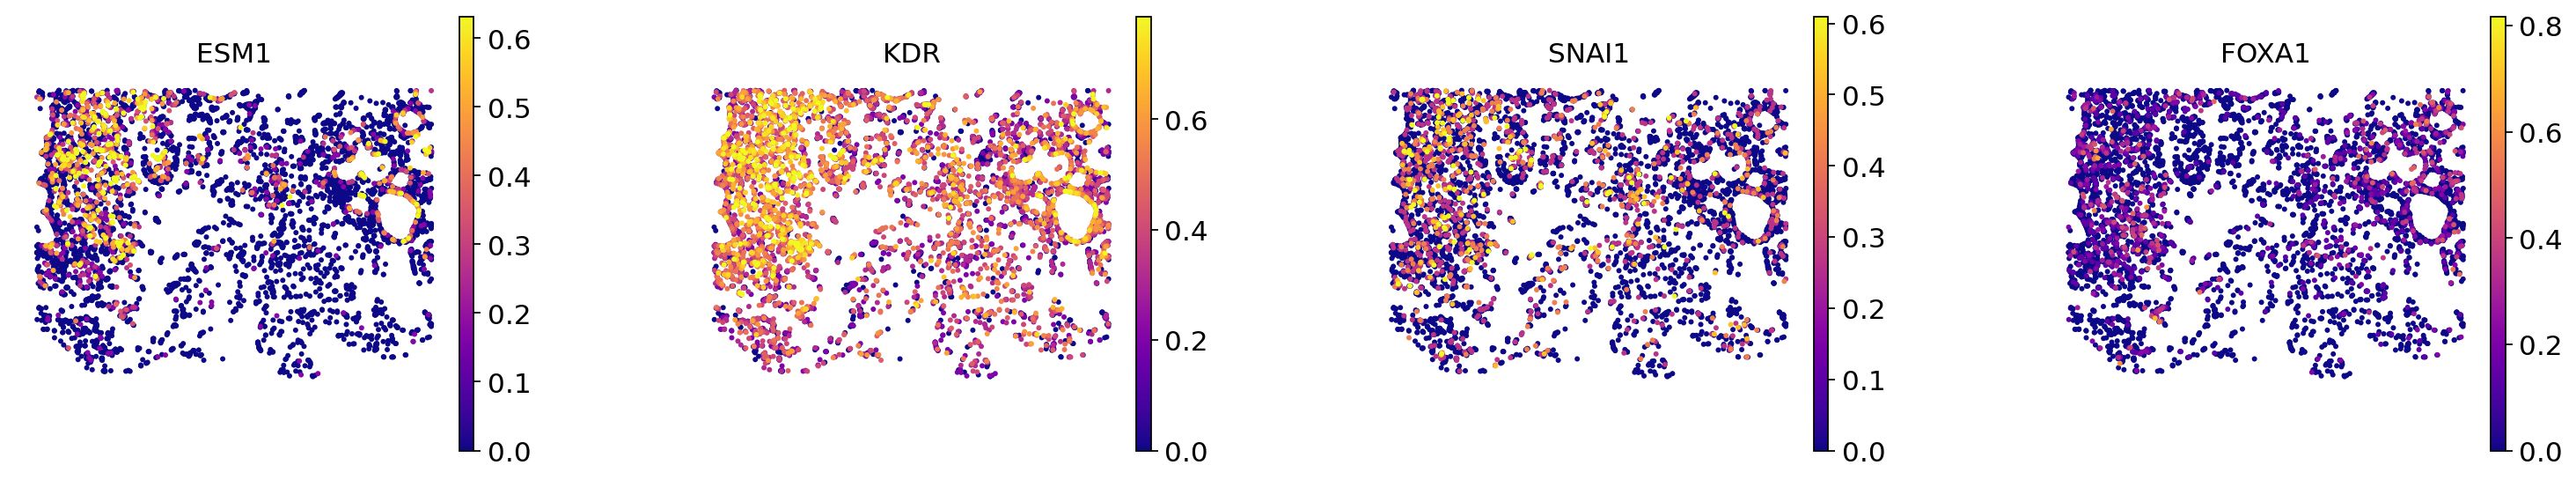

In [42]:
plot_endo = True

sc.pl.spatial(
    adata=adata_endothelial if plot_endo else adata_not_endo,
    spot_size=100 if plot_endo else 40,
    color=gene_list_invasive,
    frameon=False,
    use_raw=False,
    wspace=0.4,
    vmax=percentiles_invasive,
    layer="min_max_scaled",
    cmap="plasma",
)

Then in all cells but endothelial:

/tmp/ipykernel_1000565/1505343501.py:3: FutureWarning: The function spatial is deprecated and will be removed in the future. Use :func:`squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


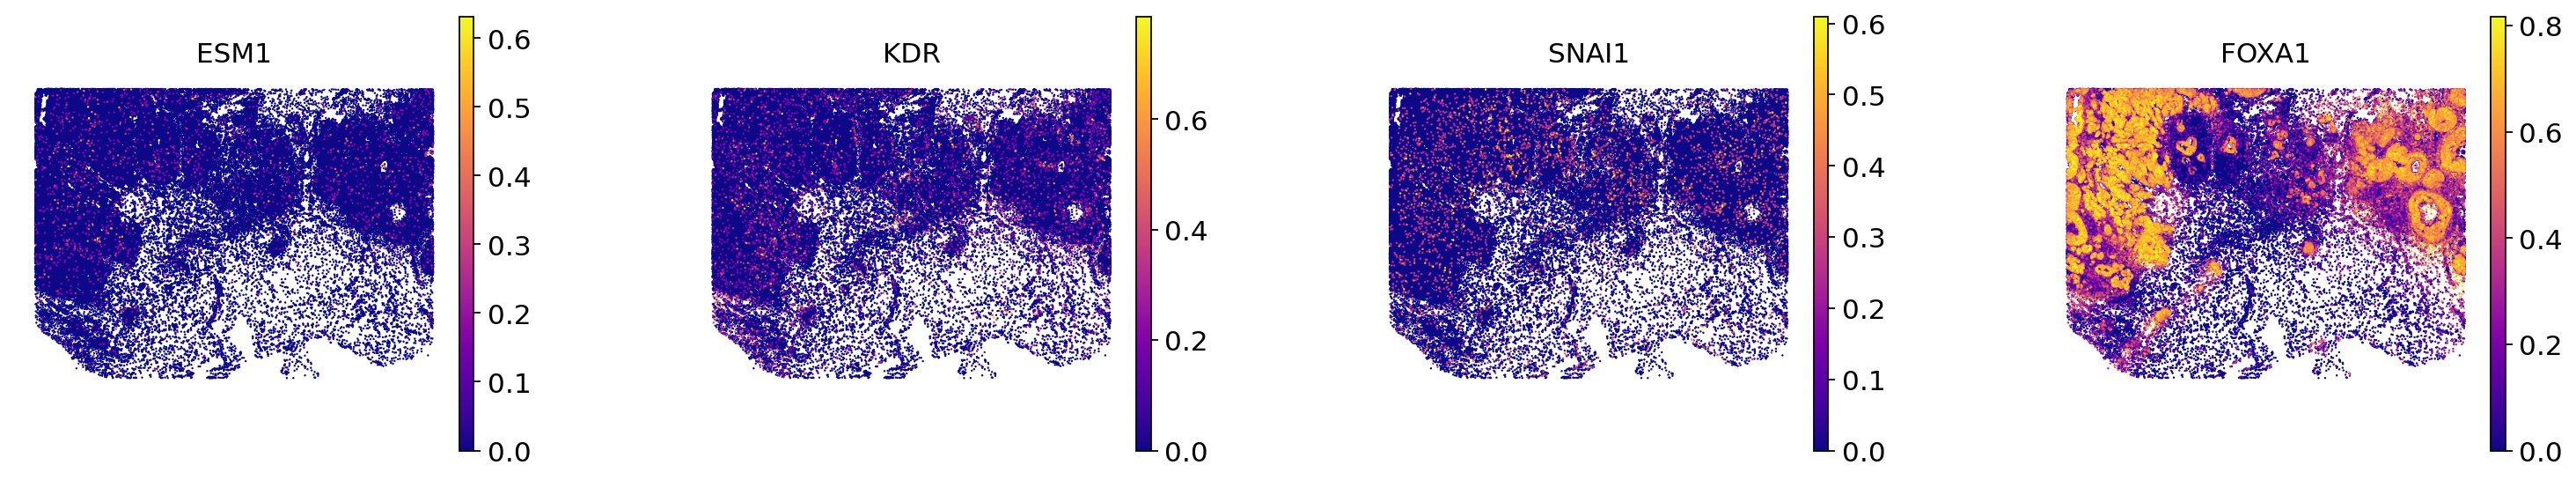

In [43]:
plot_endo = False

sc.pl.spatial(
    adata=adata_endothelial if plot_endo else adata_not_endo,
    spot_size=100 if plot_endo else 40,
    color=gene_list_invasive,
    frameon=False,
    use_raw=False,
    wspace=0.4,
    vmax=percentiles_invasive,
    layer="min_max_scaled",
    cmap="plasma",
)

## Identifying niche-dependent genes with VIVS

Beyond the joint niche/state latent space above, we can ask a more targeted question: which genes' expression is actually shaped by the cellular niche? [VIVS](https://doi.org/10.1186/s13059-024-03419-z) ({class}`~scvi.external.VIVS`) is a conditional randomization test (CRT) that yields FDR-controlled p-values per gene for conditional dependence on a chosen response `Y`, using a deep generative model as a calibrated "knockoff" sampler.

Here we reuse the niche composition that scVIVA's `preprocessing_anndata` already computed and stored in `adata.obsm["niche_composition"]` as the response `Y`. Unlike the standalone [VIVS tutorial](https://docs.scvi-tools.org/en/stable/tutorials/use_cases/VIVS_niche_gene_selection.html) (which trains a fresh plain `SCVI` knockoff sampler), we can reuse `nichevae` directly: its module (`nicheVAE`) is a `scvi.module.VAE` subclass, so VIVS can reuse its already-trained encoder/decoder (frozen) instead of fitting a new generative model.

We register the same `adata` for VIVS, with `y_obsm_key="niche_composition"` pointing at the niche composition scVIVA already computed above. Passing `x_model=nichevae` tells VIVS to reuse `nichevae`'s already-trained module (frozen) as its knockoff sampler, instead of fitting a new generative VAE — VIVS's `.train()` call then only fits the importance-score network for `Y | X`.

In [44]:
from scvi.external import VIVS
from scvi.external.vivs import plot_hier_importance

VIVS.setup_anndata(
    adata,
    y_obsm_key="niche_composition",  # niche composition computed by SCVIVA.preprocessing_anndata above
    layer="counts",  # same raw-count layer used to train scVIVA
    batch_key="sample",  # column in adata.obs that contains the batch covariate
)

vivs_model = VIVS(adata, x_model=nichevae)
vivs_model.train(max_epochs=200)

INFO     Using column names from columns of adata.obsm['niche_composition']                                        


INFO: GPU available: True (cuda), used: True
2026-09-09 14:32:03 | [INFO] GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
2026-09-09 14:32:03 | [INFO] TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
2026-09-09 14:32:03 | [INFO] 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
2026-09-09 14:32:03 | [INFO] LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/opt/anaconda3/envs/scvi_new/lib/python3.13/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `is

Training:   0%|          | 0/200 [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=200` reached.
2026-09-09 14:42:17 | [INFO] `Trainer.fit` stopped: `max_epochs=200` reached.


`get_hier_importance` clusters genes by decoder-scale correlation at several resolutions, then re-runs the conditional randomization test with group-level knockoff substitution at each resolution, giving FDR-controlled p-values both for individual genes and for coarser gene clusters. Passing `n_clusters_list=[50, 100, 200]` tests three resolutions in addition to the finest (per-gene) one.

In [45]:
res = vivs_model.get_hier_importance(
    n_clusters_list=[50, 100, 200], batch_size=8192, n_mc_samples=100
)
res

Computing hierarchical importance:   0%|          | 0/200 [00:00<?, ?it/s]

[W909 14:42:19.579442793 CUDACachingAllocator.cpp:3934] memory allocation failed with OOM on device 0 while trying to allocate 3210739712 bytes (free: 1032192000, total: 50857967616).
/opt/anaconda3/envs/scvi_new/lib/python3.13/site-packages/scvi/external/vivs/_model.py:708: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  return xr.concat(datasets, dim="resolution").reindex(gene_name=gene_order)


<xarray.Dataset> Size: 368kB
Dimensions:             (gene_name: 313, feature: 18, resolution: 4)
Coordinates:
  * gene_name           (gene_name) object 3kB 'MMP12' 'C15orf48' ... 'CLEC9A'
  * feature             (feature) int64 144B 0 1 2 3 4 5 6 ... 12 13 14 15 16 17
  * resolution          (resolution) int64 32B 50 100 200 313
    resolution_idx      (resolution) int64 32B 0 1 2 3
Data variables:
    pval                (resolution, gene_name, feature) float64 180kB 0.0693...
    padj                (resolution, gene_name, feature) float64 180kB 0.3465...
    cluster_assignment  (resolution, gene_name) int32 5kB 0 0 1 2 ... 122 47 75

`plot_hier_importance` renders the multi-resolution results as a significance dendrogram: genes/clusters found significant (BH-adjusted p-value below `significance_threshold`) at the coarsest resolution are shown, colored by significance, across all tested resolutions.

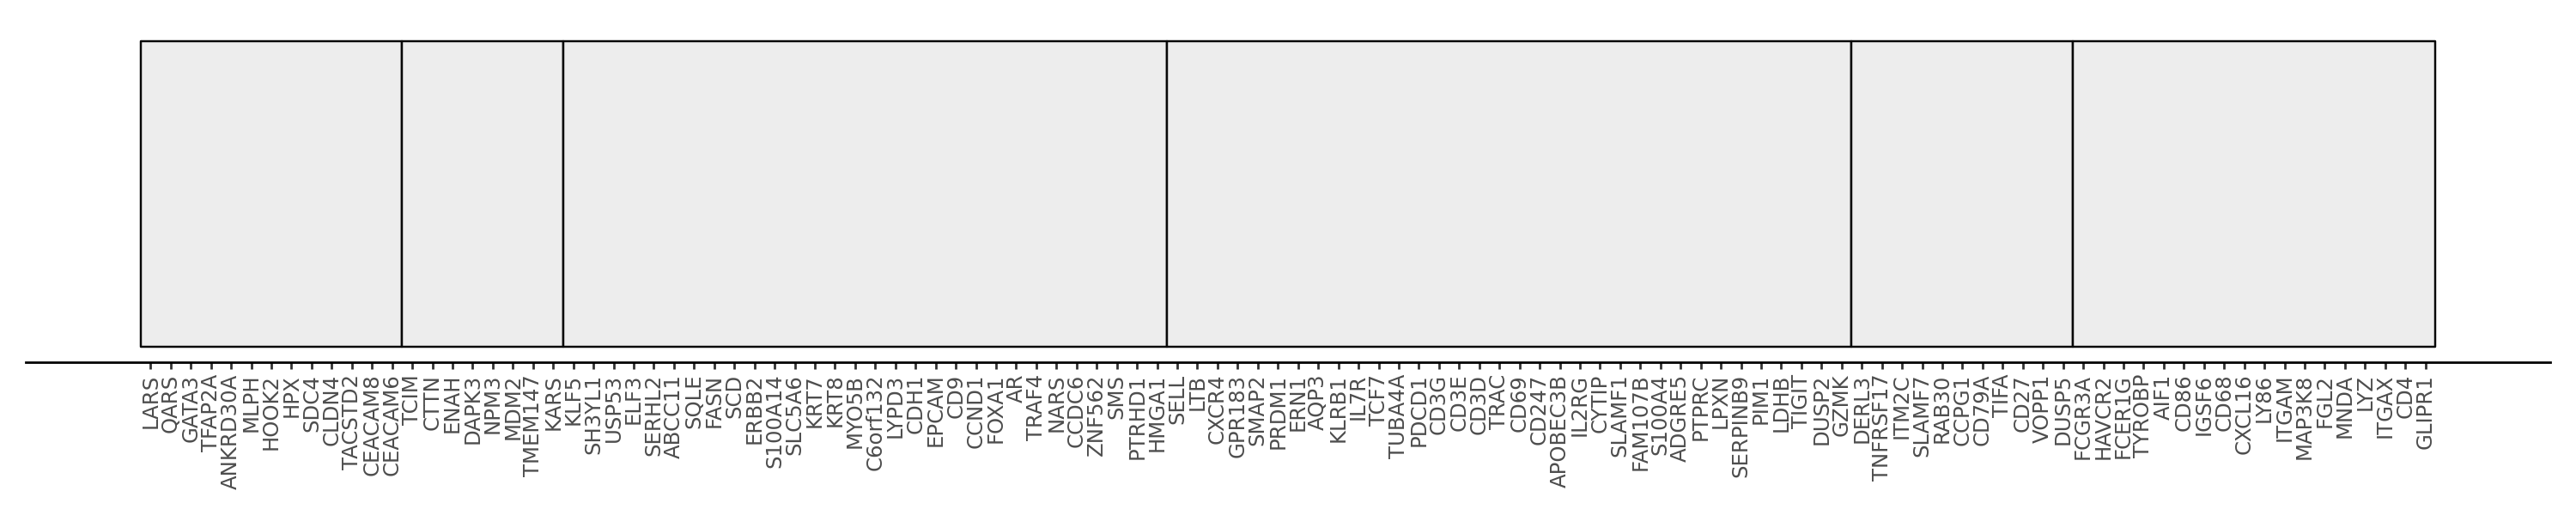

In [46]:
plot_hier_importance(res, theme_kwargs={"figure_size": (15, 3)})

In [48]:
# p-values on the held-out validation split (the default -- see `get_importance`'s docstring)
vivs_model_res = vivs_model.get_importance(indices=vivs_model.validation_indices, n_mc_samples=200)
pvalues = vivs_model_res["pvalues"][:, 0]

/tmp/ipykernel_1000565/3399031581.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


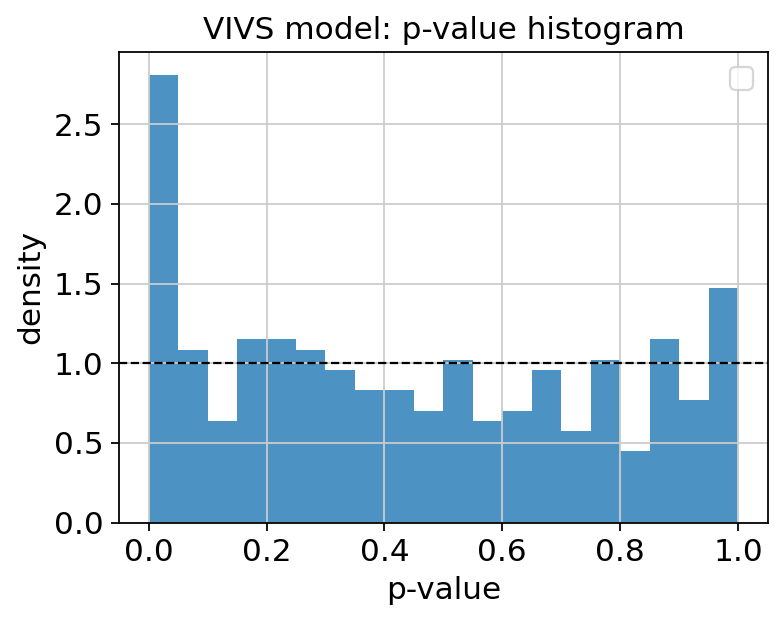

In [51]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 4))
ax.hist(pvalues, bins=20, range=(0, 1), density=True, alpha=0.8)
ax.axhline(1.0, color="black", linestyle="--", linewidth=1)
ax.set_xlabel("p-value")
ax.set_ylabel("density")
ax.set_title("VIVS model: p-value histogram")
ax.legend()
fig.tight_layout()

A gene (or gene cluster) called significant at a given resolution means the CRT rejected the null hypothesis that gene expression is conditionally independent of the niche composition `Y`, at the chosen FDR level, when knockoffs are drawn from SCVI's generative model — i.e. that gene's expression carries information about the surrounding niche beyond what is already explained by every other gene. Coarser resolutions (larger gene clusters) aggregate evidence across correlated genes and tend to have more power to detect weaker, distributed niche effects, while the finest (per-gene) resolution pinpoints individual genes.

For a per-cell rather than per-dataset view of which cells drive a given gene's (or gene cluster's) importance score, see {meth}`~scvi.external.VIVS.get_cell_scores`. For a calibration sanity check (are the p-values well-behaved on a semi-synthetic response with known ground-truth genes?), see the [VIVS tutorial](https://docs.scvi-tools.org/en/stable/tutorials/use_cases/VIVS_niche_gene_selection.html).

In [47]:
import gc

gc.collect()
import torch

torch.cuda.empty_cache()